In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv("candy.csv")
df

,id,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,0,100 Grand,Yes,No,Yes,No,No,Yes,No,Yes,No,0.732,0.860,66.971725
1,1,3 Musketeers,Yes,No,No,No,Yes,No,No,Yes,No,0.604,0.511,67.602936
2,2,Air Heads,No,Yes,No,No,No,No,No,No,No,0.906,0.511,52.341465
3,3,Almond Joy,Yes,No,No,Yes,No,No,No,Yes,No,0.465,0.767,50.347546
4,4,Baby Ruth,Yes,No,Yes,Yes,Yes,No,No,Yes,No,0.604,0.767,56.914547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,78,Twizzlers,No,Yes,No,No,No,No,No,No,No,0.220,0.116,45.466282
79,79,Warheads,No,Yes,No,No,No,No,Yes,No,No,0.093,0.116,39.011898
80,80,Welch's Fruit Snacks,No,Yes,No,No,No,No,No,No,Yes,0.313,0.313,44.375519
81,81,Werther's Original Caramel,No,No,Yes,No,No,No,Yes,No,No,0.186,0.267,41.904308


In [3]:
# Datos
X = df[['pricepercent']]     # matriz n×1 (precio)
y = df['winpercent']         # vector n (ventas)

In [4]:
#correlacion
r, p_value = pearsonr(df['pricepercent'], df['winpercent'])
print(f"Coeficiente de correlación r = {r:.4f}")

Coeficiente de correlación r = 0.3339


In [5]:
#determinacon
model = LinearRegression()
model.fit(X, y)
b0 = model.intercept_
b1 = model.coef_[0]
R2 = model.score(X, y)

print(f"Modelo: ventas = {b0:.2f} + {b1:.2f} * precio")
print(f"R^2 (coef. de determinación) = {R2:.4f}")

Modelo: ventas = 42.46 + 17.19 * precio
R^2 (coef. de determinación) = 0.1115


In [6]:
#predicción de pricepercent = 0.95
precio_nuevo = 0.95
venta_predicha = model.predict([[precio_nuevo]])[0]
print(f"Predicción para pricepercent = {precio_nuevo:.2f}: "
      f"ventas ≈ {venta_predicha:.2f}")

Predicción para pricepercent = 0.95: ventas ≈ 58.79


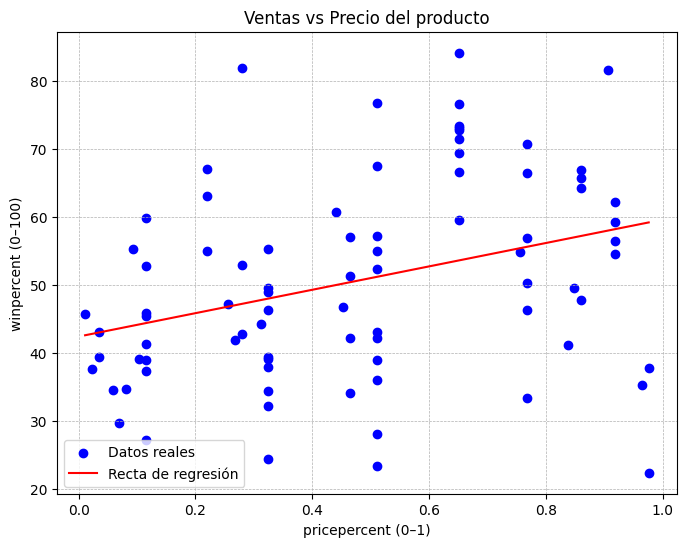

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(df['pricepercent'], y, color='blue', label='Datos reales')
x_line = np.linspace(df['pricepercent'].min(), df['pricepercent'].max(), 100)
y_line = model.predict(x_line.reshape(-1,1))
plt.plot(x_line, y_line, color='red', label='Recta de regresión')
plt.title("Ventas vs Precio del producto")
plt.xlabel("pricepercent (0–1)")
plt.ylabel("winpercent (0–100)")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()
